In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pycaret.time_series import setup, create_model, tune_model, plot_model, predict_model

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [6]:
data = pd.read_csv("data.csv", parse_dates = ["timestamp"], index_col="timestamp")
data.head()

,temp,SOLAR,BIOMASS,WIND_ONSHORE,NUCLEAR,consommation_totale
timestamp,,,,,,
2020-01-01 00:00:00,0.8,0.0,348.0,2810.0,49462.0,63191.75
2020-01-01 01:00:00,-0.7,0.0,347.0,2655.0,49565.0,61903.75
2020-01-01 02:00:00,-0.3,0.0,348.0,2736.0,49580.0,58716.00
2020-01-01 03:00:00,0.0,0.0,348.0,2631.0,49271.0,56448.25
2020-01-01 04:00:00,0.3,0.0,347.0,2533.0,49438.0,55891.00


In [9]:
data["production_totale"] = data[["SOLAR", "BIOMASS", "WIND_ONSHORE", "NUCLEAR"]].sum(axis=1)
data.head()

,temp,SOLAR,BIOMASS,WIND_ONSHORE,NUCLEAR,consommation_totale,production_totale
timestamp,,,,,,,
2020-01-01 00:00:00,0.8,0.0,348.0,2810.0,49462.0,63191.75,52620.0
2020-01-01 01:00:00,-0.7,0.0,347.0,2655.0,49565.0,61903.75,52567.0
2020-01-01 02:00:00,-0.3,0.0,348.0,2736.0,49580.0,58716.00,52664.0
2020-01-01 03:00:00,0.0,0.0,348.0,2631.0,49271.0,56448.25,52250.0
2020-01-01 04:00:00,0.3,0.0,347.0,2533.0,49438.0,55891.00,52318.0


In [10]:
data.drop(columns=["SOLAR", "BIOMASS", "WIND_ONSHORE", "NUCLEAR"], axis=1, inplace=True)
data.head()

,temp,consommation_totale,production_totale
timestamp,,,
2020-01-01 00:00:00,0.8,63191.75,52620.0
2020-01-01 01:00:00,-0.7,61903.75,52567.0
2020-01-01 02:00:00,-0.3,58716.00,52664.0
2020-01-01 03:00:00,0.0,56448.25,52250.0
2020-01-01 04:00:00,0.3,55891.00,52318.0


In [22]:
df = data.copy()
df.drop(columns=["temp"], axis=1, inplace=True)
df.reset_index(inplace=True)

In [23]:
vars = ["consommation_totale", "production_totale"]
df = df.melt(id_vars="timestamp", value_vars=vars, var_name="unique_id", value_name="y")
df.rename(columns={"timestamp": "ds"}, inplace=True)
df.head()

,ds,unique_id,y
0,2020-01-01 00:00:00,consommation_totale,63191.75
1,2020-01-01 01:00:00,consommation_totale,61903.75
2,2020-01-01 02:00:00,consommation_totale,58716.00
3,2020-01-01 03:00:00,consommation_totale,56448.25
4,2020-01-01 04:00:00,consommation_totale,55891.00


In [32]:
start_date = "2020-01-01"
end_date = "2025-09-17"

dataset = df[(df["ds"] >= start_date) & (df["ds"] <= end_date)]

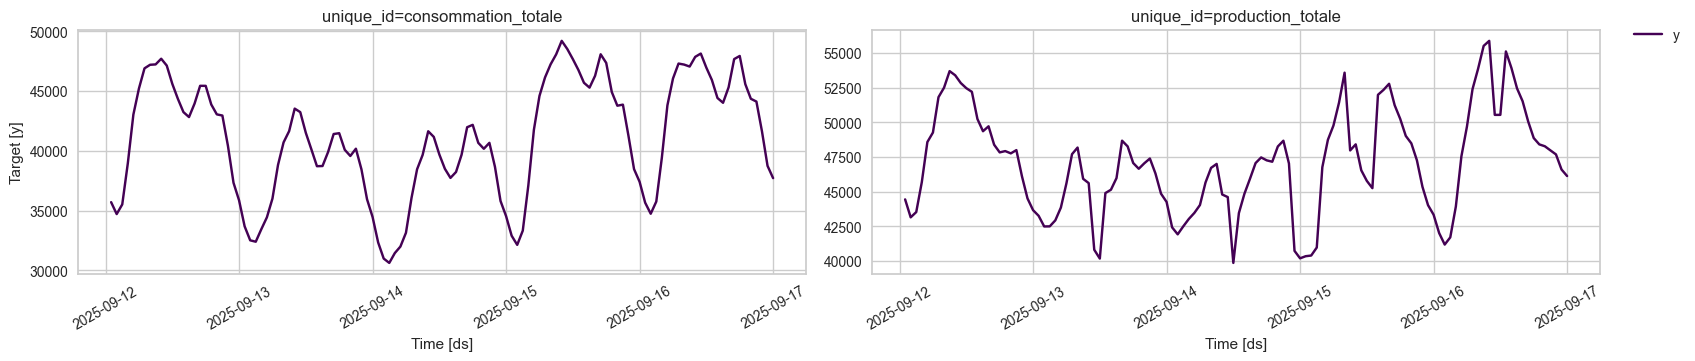

In [33]:
plot_series(df=dataset, ids=["consommation_totale", "production_totale"], max_insample_length=5*24, palette="viridis")

In [34]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

horizon = 24

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=horizon),
    SeasonalNaive(season_length=horizon)
]

sf = StatsForecast(models=models, freq="h")
sf.fit(df=dataset)
preds = sf.predict(h=horizon)

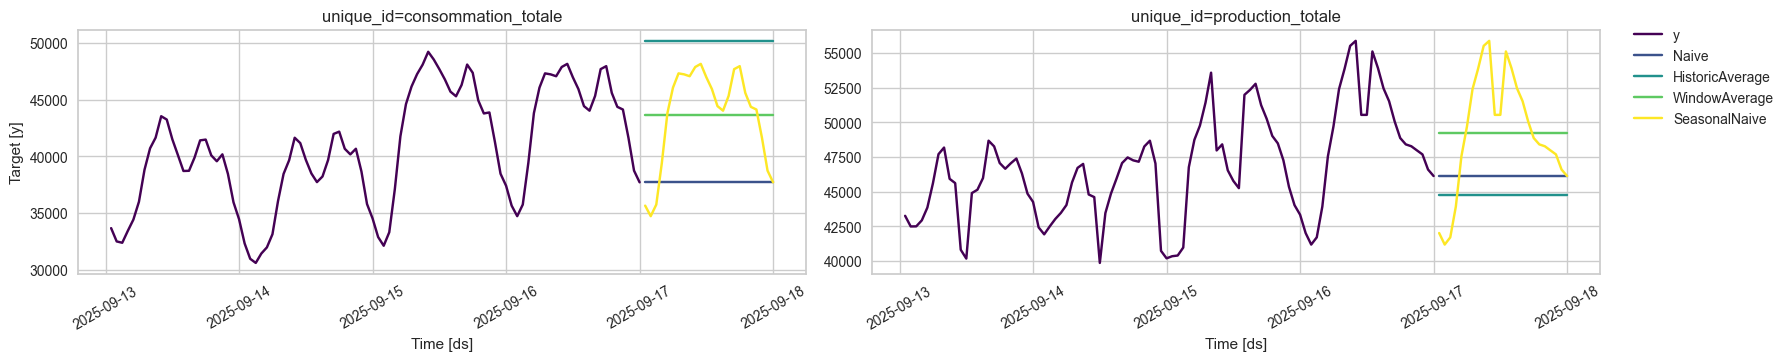

In [36]:
plot_series(
    df=dataset,
    forecasts_df=preds,
    ids=["consommation_totale", "production_totale"],
    max_insample_length=24*4,
    palette="viridis")

In [37]:
test = dataset.groupby("unique_id").tail(24)
train = dataset.drop(test.index).reset_index(drop=True)

In [38]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

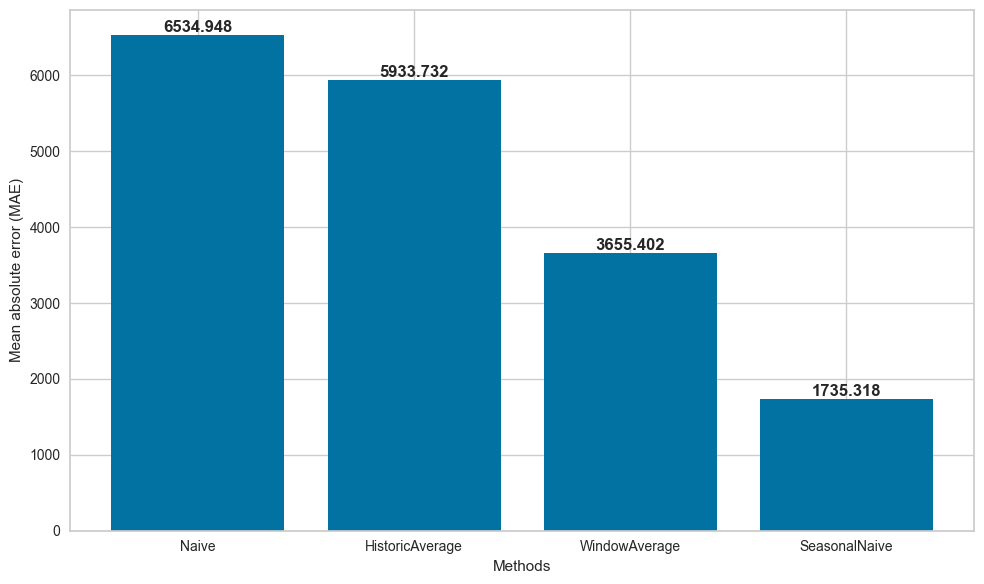

In [39]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

In [41]:
train_df=train[train["ds"] < "2023-12-31"]
test_df=train_df.groupby("unique_id").tail(24)
train_df=train_df.drop(test_df.index).reset_index(drop=True)
train_df.shape

(70032, 3)

In [ ]:
from statsforecast.models import AutoARIMA

unique_ids = ["consommation_totale", "production_totale"]

small_train = train_df[train_df["unique_id"].isin(unique_ids)]
small_test = test_df[test_df["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=horizon, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="h")
sf.fit(df=small_train)
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

: 

In [ ]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

In [ ]:
plot_series(
    df=small_train,
    forecasts_df=arima_preds,
    ids=["consommation_totale", "SOLAR"],
    max_insample_length=24*4,
    palette="viridis")